In [1]:
import os
import json
import shutil
import pickle
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization, Bidirectional, MaxPooling1D, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from keras.utils import plot_model
from tensorflow.keras.models import Model


2024-12-17 02:40:03.408068: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-17 02:40:04.061028: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# check if the gpu support available
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2024-12-17 02:40:04.675850: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-17 02:40:04.703718: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-17 02:40:04.704060: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [3]:
data_directory = '../all_outputs/output_holistic_pickle_wlasl2/'
meta_data_file = '../WLASL_v0.3.json'

In [4]:
content = json.load(open(meta_data_file))
filenames = set(os.listdir(data_directory))

In [5]:
# Shape of dataset (videos, frames, landmarks_fflattened)
# Number of videos = number of files in data_directory
# We take 24 frames from each video
# 

all_data = []

In [ ]:
with open(data_directory + "09956.pkl", 'rb') as f:
        land_marks = pickle.load(f)
        # print the format of read data
        print(land_marks[0].keys())
        print(len(land_marks[10]['left_hand_landmarks']))

dict_keys(['pose_landmarks', 'face_landmarks', 'left_hand_landmarks', 'right_hand_landmarks'])


IndexError: list index out of range

In [ ]:
# Define indices for points of interest
pose_indices = [0, 11, 12, 13, 14, 15, 16, 23, 24]
hand_indices = [0, 1, 3, 4, 6, 8, 10, 12, 14, 16, 18, 20]

In [ ]:

def load_landmarks(content, filenames, data_directory, num_frames):
    
    
    # Prepare storage for data and labels
    video_data = []
    labels = []
    
    for entry in content:
        instances = entry['instances']
        gloss = entry['gloss']  # label for current video

        for inst in instances:
            file_id = inst['video_id']
            if file_id + '.pkl' in filenames:
                with open(os.path.join(data_directory, file_id + '.pkl'), 'rb') as f:
                    landmarks = pickle.load(f)
                    
                    # Prepare frame storage for each video with fixed number of frames
                    frames = []

                    # Get frame sampling step (skip frames if necessary)
                    total_frames = len(landmarks)
                    step = max(1, total_frames // num_frames)
                    
                    # Process frames
                    for i in range(num_frames):
                        frame_index = i * step if total_frames >= num_frames else i
                        
                        if frame_index < total_frames:
                            frame = landmarks[frame_index]
                        else:
                            frame = None
                        
                        # Extract and flatten required points
                        pose_points = frame['pose_landmarks'] if frame and frame['pose_landmarks'] else [None] * 33
                        left_hand_points = frame['left_hand_landmarks'] if frame and frame['left_hand_landmarks'] else [None] * 21
                        right_hand_points = frame['right_hand_landmarks'] if frame and frame['right_hand_landmarks'] else [None] * 21
                        
                        # Collect only specified indices and flatten them
                        extracted_points = []

                        # Collect pose points first
                        for idx in pose_indices:
                            point = pose_points[idx] if pose_points[idx] is not None else {'x': 0, 'y': 0}
                            extracted_points.extend([point['x'], point['y']])
                        
                        # print(left_hand_points)
                        for idx in hand_indices:
                            point = left_hand_points[idx] if left_hand_points[idx] is not None else {'x': 0, 'y': 0}
                            extracted_points.extend([point['x'], point['y']])

                        # Collect right hand points
                        for idx in hand_indices:
                            point = right_hand_points[idx] if right_hand_points[idx] is not None else {'x': 0, 'y': 0}
                            extracted_points.extend([point['x'], point['y']])
                        
                        frames.append(extracted_points)
                    
                    # Add the processed video frames to the main array
                    video_data.append(frames)
                    labels.append(gloss)

    # Convert to numpy arrays
    video_data = np.array(video_data)
    labels = np.array(labels)
    
    return video_data, labels

# Example usage
num_frames = 30  # Desired fixed number of frames per video

video_data, labels = load_landmarks(content, filenames, data_directory, num_frames)

# `video_data` has shape (number of videos, num_frames, number of points*2) where points*2 is the flattened landmark count
# `labels` contains the labels for each video


In [ ]:
NUM_CLASSES = len(set(labels))
NUM_CLASSES

20

In [ ]:
# Encode labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
labels_one_hot = to_categorical(labels_encoded, num_classes=NUM_CLASSES)

# Split dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(video_data, labels_one_hot, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)



In [ ]:
# print train, val, test shapes
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(170, 30, 66) (170, 20)
(36, 30, 66) (36, 20)
(37, 30, 66) (37, 20)


In [ ]:
# input_shape=(num_frames, len(pose_indices) * 2 + len(hand_indices) * 2 * 2)

In [ ]:
# Load saved model
pre_trained_model = tf.keras.models.load_model('../saved_models/exp_3_1/model_2.h5')

NameError: name 'tf' is not defined

In [ ]:
# Print the original model summary
pre_trained_model.summary()

# Get the output of the second-to-last layer
base_output = pre_trained_model.layers[-2].output  # This gets output from 'global_max_pooling1d'

# Create a new model without the last layer
model = Model(inputs=pre_trained_model.input, outputs=base_output)

# Add a new output layer if required
new_output = Dense(NUM_CLASSES, activation='softmax', name="new_output_layer")(model.output)
model = Model(inputs=model.input, outputs=new_output)

# Print the new model summary
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_1 (Dropout)         (None, 30, 66)            0         
                                                                 
 batch_normalization_1 (Bat  (None, 30, 66)            264       
 chNormalization)                                                
                                                                 
 bidirectional_4 (Bidirecti  (None, 30, 512)           661504    
 onal)                                                           
                                                                 
 bidirectional_5 (Bidirecti  (None, 30, 512)           1574912   
 onal)                                                           
                                                                 
 bidirectional_6 (Bidirecti  (None, 30, 512)           1574912   
 onal)                                                

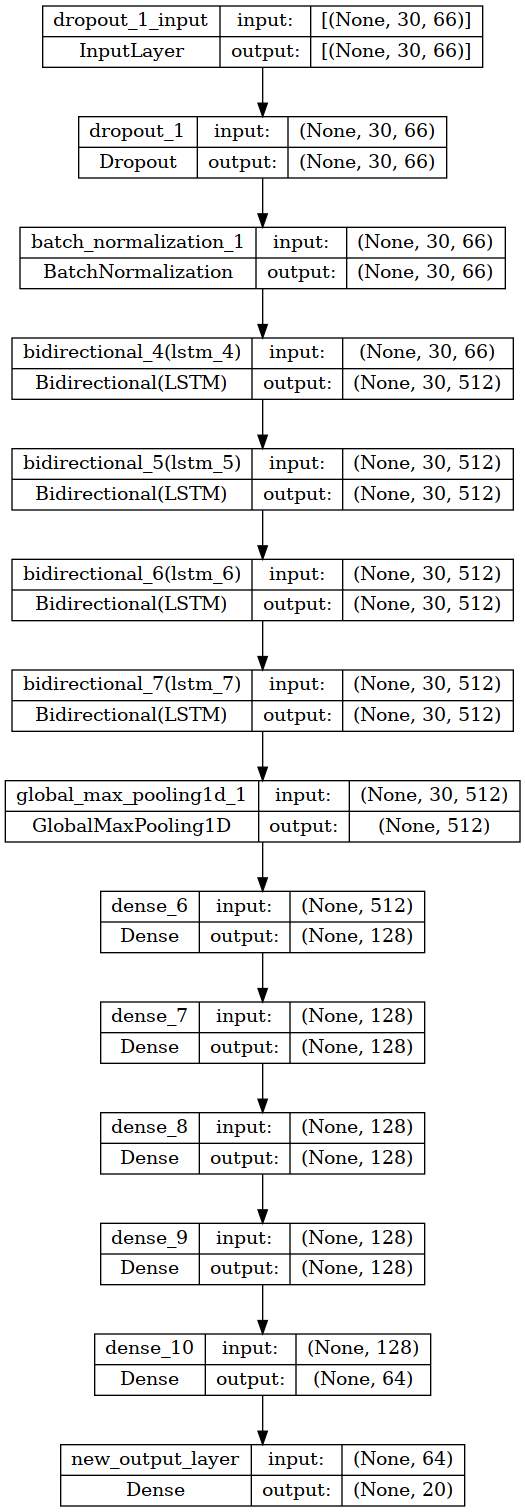

In [ ]:
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

In [ ]:
# Compile the Model
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32)


# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")




# Save label encoder and model if needed
# joblib.dump(label_encoder, 'label_encoder.pkl')
# model.save('lstm_landmark_model.h5')

Epoch 1/60
6/6 [==============================] - 12s 390ms/step - loss: 4.3652 - accuracy: 0.0353 - val_loss: 2.9617 - val_accuracy: 0.0556
Epoch 2/60
6/6 [==============================] - 0s 35ms/step - loss: 3.0075 - accuracy: 0.0471 - val_loss: 2.9507 - val_accuracy: 0.0278
Epoch 3/60
6/6 [==============================] - 0s 33ms/step - loss: 2.9268 - accuracy: 0.1059 - val_loss: 2.9581 - val_accuracy: 0.0278
Epoch 4/60
6/6 [==============================] - 0s 33ms/step - loss: 2.8952 - accuracy: 0.1059 - val_loss: 2.9114 - val_accuracy: 0.0278
Epoch 5/60
6/6 [==============================] - 0s 33ms/step - loss: 2.8354 - accuracy: 0.1176 - val_loss: 2.8527 - val_accuracy: 0.0556
Epoch 6/60
6/6 [==============================] - 0s 32ms/step - loss: 2.7928 - accuracy: 0.1235 - val_loss: 2.7830 - val_accuracy: 0.0556
Epoch 7/60
6/6 [==============================] - 0s 32ms/step - loss: 2.7444 - accuracy: 0.1529 - val_loss: 2.7474 - val_accuracy: 0.0000e+00
Epoch 8/60
6/6 [=====

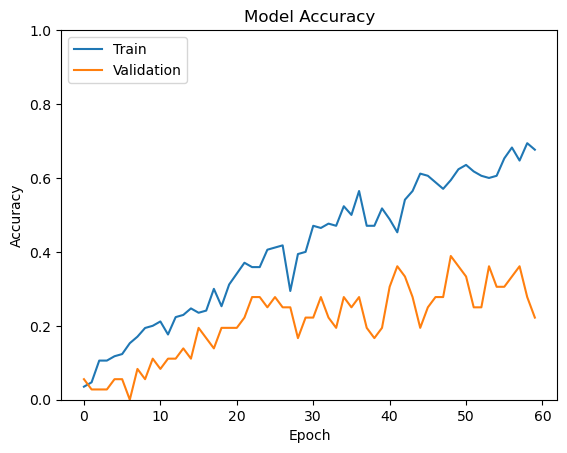

In [ ]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

# Ensure the y-axis always includes 1.0 as the maximum
plt.ylim(0, 1.0)

plt.legend(['Train', 'Validation'], loc='upper left')
save_plt = plt
plt.show()


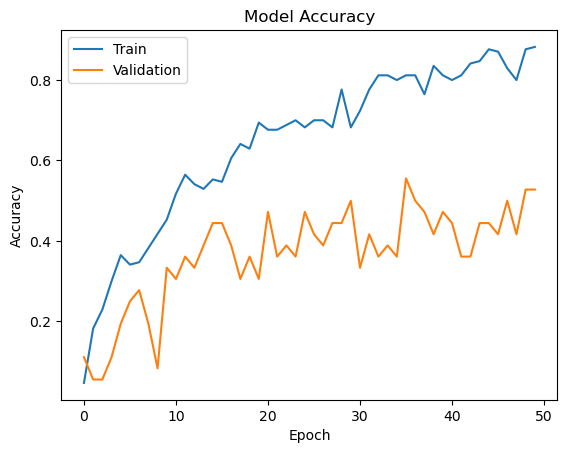

In [ ]:
exp_number = 4
description = "Fine tune a model that was trained on sinhala data set (450 videos and 20 classes) using smaller english dataset (250 videos and 20 classes)"

# create folder to store results and store results if folder is already there, show error
if not os.path.exists('../Results/exp_' + str(exp_number)):
    os.makedirs('../Results/exp_' + str(exp_number))

    with open('../Results/exp_' + str(exp_number) + '/description.txt', 'w') as f:
        f.write(description)

    # also save plots
        plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.savefig('../Results/exp_' + str(exp_number) + '/accuracy.png')


else:
    print("Folder already exists")


In [ ]:

# Define model parameters
input_dim = 512  # Adjust this based on your input feature size
hidden_dim = 256
output_dim = 10  # Adjust this based on the number of sign language classes

# Define the model architecture
class SignLanguageModel(tf.keras.Model):
    def __init__(self):
        super(SignLanguageModel, self).__init__()
        
        # Batch normalization layer
        self.batch_norm = tf.keras.layers.BatchNormalization()
        
        # Projection to lower dimension
        self.projection_layer = tf.keras.layers.Dense(input_dim, activation='relu')
        
        # Dropout layer
        self.dropout = tf.keras.layers.Dropout(0.2)
        
        # Two-layer BiLSTM
        self.bi_lstm1 = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(hidden_dim, return_sequences=True))
        self.bi_lstm2 = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(hidden_dim, return_sequences=True))
        
        # Max pooling layer
        self.max_pooling = tf.keras.layers.GlobalMaxPooling1D()
        
        # Output linear layer
        self.output_layer = tf.keras.layers.Dense(output_dim)
        
        # Softmax for classification
        self.softmax = tf.keras.layers.Softmax()

    def call(self, inputs, training=False):
        # Normalize inputs
        x = self.batch_norm(inputs, training=training)
        
        # Project to lower dimension
        x = self.projection_layer(x)
        
        # Apply dropout
        x = self.dropout(x, training=training)
        
        # BiLSTM layers
        x = self.bi_lstm1(x)
        x = self.bi_lstm2(x)
        
        # Max pooling
        x = self.max_pooling(x)
        
        # Final linear layer and softmax
        x = self.output_layer(x)
        x = self.softmax(x)
        
        return x

# Instantiate the model
model = SignLanguageModel()

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Example usage: Assuming `train_dataset` is a tf.data.Dataset containing (features, labels)
# model.fit(train_dataset, epochs=10, batch_size=512)
